### Необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from datetime import timedelta

### Загружаем исходные для анализа файлы. В данном случае загружаем файлы в виртуальную машишу.

In [3]:
df = pd.read_csv('data.csv.zip', encoding='latin_1')

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Приводим в соотвествие тип данных в колонке с датами

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

### Работаем с пропущенными значениями

In [8]:
print("В наших данных {} строк и {} колонок".format(df.shape[0], df.shape[1]))

В наших данных 541909 строк и 8 колонок


In [13]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [10]:
df['Description'] = df['Description'].fillna('New product')

In [11]:
df = df.dropna()

### Убеждаемся, что ID Заказчика - это INT

In [14]:
### df['CustomerID'] = df['CustomerID'].apply(lambda x: int(x))
df['CustomerID'] = df['CustomerID'].astype('int32')

In [15]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


### Создаем колонку с общими доходами по строке и определяем дату отчета

In [16]:
df['TotalSum'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSum
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [17]:
snapshot_date = df['InvoiceDate'].max() + timedelta(days = 1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [ ]:
df['Country'].value_counts()

In [22]:
df_ = df[df['Quantity']>0]

In [21]:
df[df['InvoiceNo'].str.startswith('C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSum
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,-6.96
...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom,-9.13
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom,-224.69
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom,-54.75
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom,-1.25


### Создаем агрегаты по каждой метрике

In [23]:
data_process = df_.groupby('CustomerID').agg({
    'InvoiceDate':lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo' : 'count',
    'TotalSum'  : 'sum'
})

In [24]:
data_process.head()

,InvoiceDate,InvoiceNo,TotalSum
CustomerID,,,
12346,326,1,77183.60
12347,2,182,4310.00
12348,75,31,1797.24
12349,19,73,1757.55
12350,310,17,334.40


In [25]:
data_process = data_process.rename(columns={
    'InvoiceDate':'Recency',
    'InvoiceNo' : 'Frequency',
    'TotalSum' : 'Monetary'
})

### Графики распределения по каждой метрике

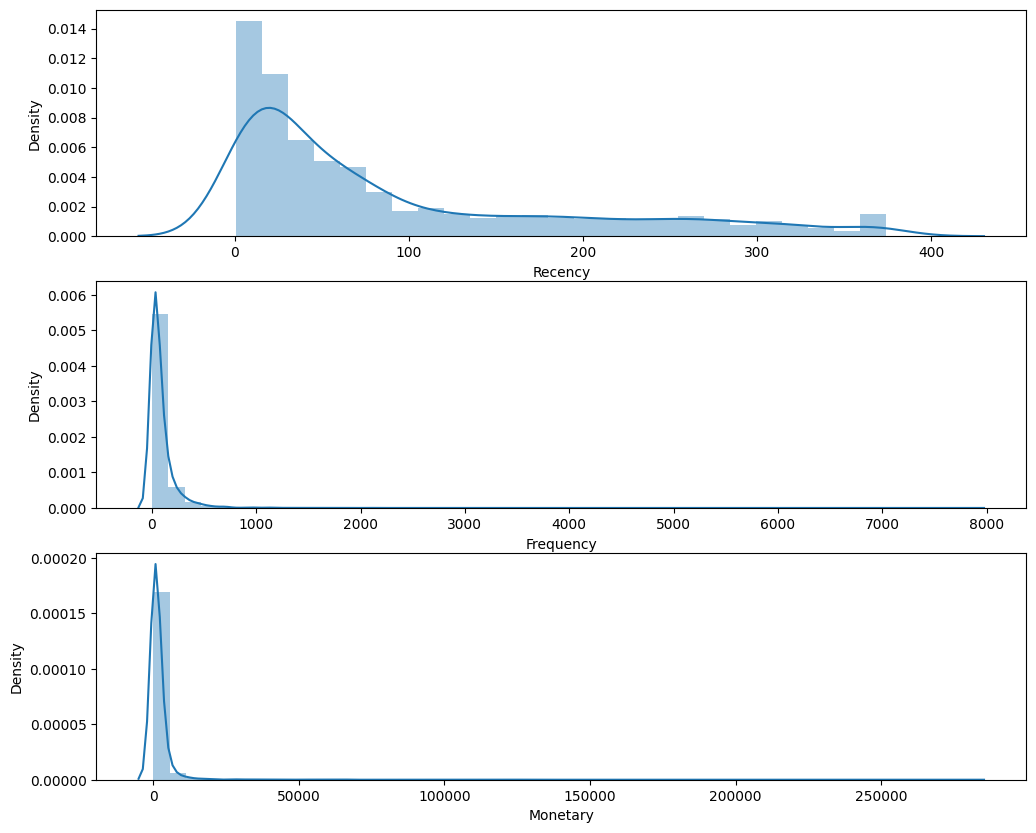

In [26]:
plt.figure(figsize=(12,10))
plt.subplot(3,1,1); sns.distplot(data_process['Recency'])
plt.subplot(3,1,2); sns.distplot(data_process['Frequency'])
plt.subplot(3,1,3); sns.distplot(data_process['Monetary'])
plt.show()

### Сглаживаем распределение

In [27]:
data_process['Recency_log'] = np.where(data_process['Recency'] == 0, 0, np.log(data_process['Recency']))
data_process['Frequency_log'] = np.where(data_process['Frequency'] == 0, 0, np.log(data_process['Frequency']))
data_process['Monetary_log'] = np.where(data_process['Monetary'] == 0, 0, np.log(data_process['Monetary']))

In [28]:
data_process.head()

,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log
CustomerID,,,,,,
12346,326,1,77183.60,5.786897,0.000000,11.253942
12347,2,182,4310.00,0.693147,5.204007,8.368693
12348,75,31,1797.24,4.317488,3.433987,7.494007
12349,19,73,1757.55,2.944439,4.290459,7.471676
12350,310,17,334.40,5.736572,2.833213,5.812338


<Axes: xlabel='Monetary_log', ylabel='Density'>

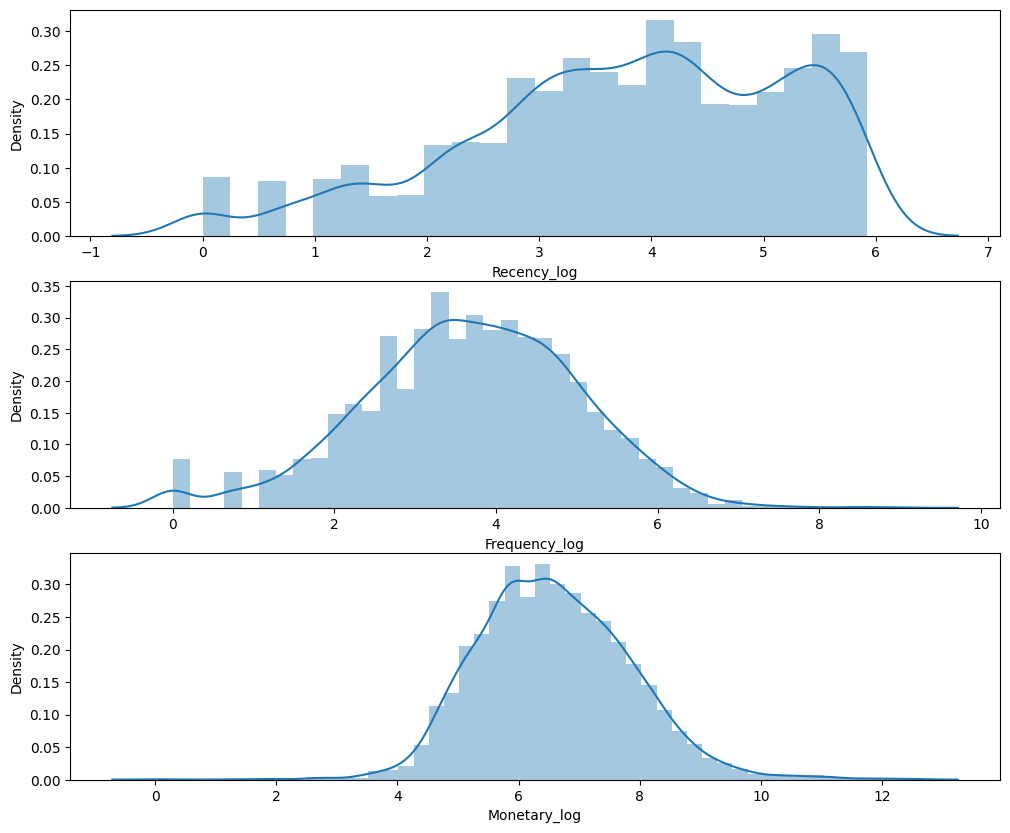

In [29]:
plt.figure(figsize=(12,10))
plt.subplot(3,1,1); sns.distplot(data_process['Recency_log'])
plt.subplot(3,1,2); sns.distplot(data_process['Frequency_log'])
plt.subplot(3,1,3); sns.distplot(data_process['Monetary_log'])

### Создаем классы для сегментации по каждой метрике

In [30]:
r_labels = range(5, 0, -1)
f_labels = range(1, 6)
m_labels = range(1, 6)

### pd.qcut

r_groups = pd.cut(data_process['Recency_log'], bins = 5, labels=r_labels)
f_groups = pd.cut(data_process['Frequency_log'], bins = 5, labels=f_labels)
m_groups = pd.cut(data_process['Monetary_log'], bins = 5, labels=m_labels)

data_process = data_process.assign(R = r_groups.values, F = f_groups.values, M = m_groups.values)

In [31]:
data_process.head()

,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,R,F,M
CustomerID,,,,,,,,,
12346,326,1,77183.60,5.786897,0.000000,11.253942,1,1,5
12347,2,182,4310.00,0.693147,5.204007,8.368693,5,3,4
12348,75,31,1797.24,4.317488,3.433987,7.494007,2,2,3
12349,19,73,1757.55,2.944439,4.290459,7.471676,3,3,3
12350,310,17,334.40,5.736572,2.833213,5.812338,1,2,3


In [33]:
rfm_table = data_process.pivot_table(
    index = 'F',
    columns = 'R',
    values = 'Monetary',
    aggfunc = np.mean
)

In [34]:
rfm_table

R,5,4,3,2,1
F,,,,,
1,28882.050000,176.314286,511.116226,397.062105,839.009024
2,1252.770667,759.485238,565.667348,583.944643,450.968416
3,3464.062878,3021.550437,1865.780561,1523.418852,1037.930918
4,11287.067529,9434.473800,6286.906454,5455.761020,2575.033750
5,79743.353750,63496.540000,NaN,NaN,NaN


### Рисуем тепловую карту

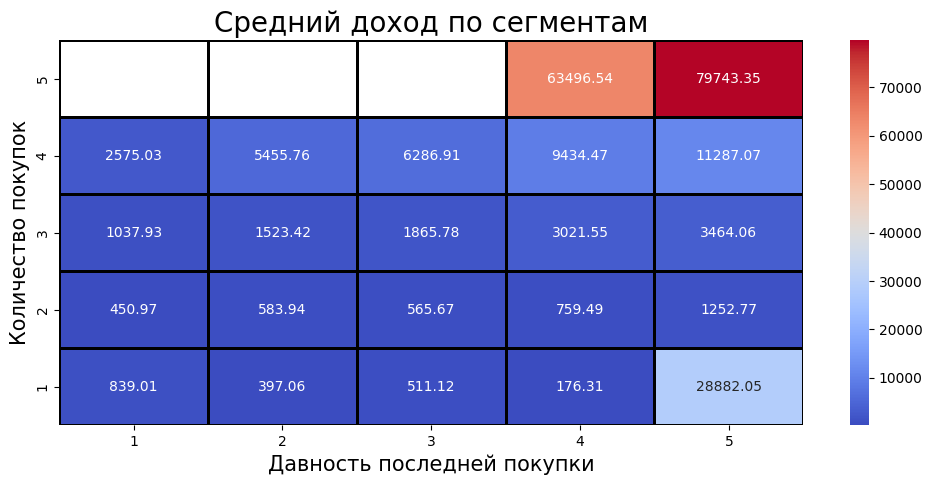

In [32]:
rfm_table = data_process.pivot_table(
    index = 'F',
    columns = 'R',
    values = 'Monetary',
    aggfunc = np.mean
).applymap(float)


plt.figure(figsize = (12,5))
sns.heatmap(rfm_table, annot = True, fmt = "0.2f", linewidths = 1, linecolor = 'black', cmap = 'coolwarm')
plt.title("Средний доход по сегментам", fontsize = 20, color = 'black')
plt.xlabel('Давность последней покупки', fontsize = 15, color = 'black')
plt.ylabel('Количество покупок', fontsize = 15, color = 'black')

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.show()

In [ ]:
rfm_table

### Понятные классы для каждой метрики

In [37]:
segm_map = {
    r'[1-2][1-2]' : 'в зоне бездействия',
    r'[1-2][3-4]' : 'в зоне риска',
    r'[1-2]5' : 'не можем потерять',
    r'3[1-2]' : 'засыпающий',
    r'33' : 'нуждающийся во внимании',
    r'[3-4][4-5]' : 'постоянный покупатель',
    r'41' : 'перспективный пользователь',
    r'51' : 'последний пользователь',
    r'[4-5][2-3]' : 'потенциальный лоялист',
    r'5[4-5]' : 'чемпион',
}

data_process['Segment'] = data_process['R'].astype(str) + data_process['F'].astype(str)
data_process['Segment'] = data_process['Segment'].replace(segm_map, regex = True)

In [38]:
data_process.head()

,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,R,F,M,Segment
CustomerID,,,,,,,,,,
12346,326,1,77183.60,5.786897,0.000000,11.253942,1,1,5,в зоне бездействия
12347,2,182,4310.00,0.693147,5.204007,8.368693,5,3,4,потенциальный лоялист
12348,75,31,1797.24,4.317488,3.433987,7.494007,2,2,3,в зоне бездействия
12349,19,73,1757.55,2.944439,4.290459,7.471676,3,3,3,нуждающийся во внимании
12350,310,17,334.40,5.736572,2.833213,5.812338,1,2,3,в зоне бездействия


In [39]:
frm_level_agg = data_process.groupby('Segment').agg({
    'Recency' : 'mean',
    'Frequency' : 'mean',
    'Monetary' : ['mean','count']
}).round(1)

frm_level_agg.columns = frm_level_agg.columns.droplevel()
frm_level_agg.columns = ['Ср_дней_с_посл_покуп','Ср_колво_покупок','Ср_выручка','Колво_человек']
frm_level_agg.sort_values(by='Колво_человек',ascending=False)

,Ср_дней_с_посл_покуп,Ср_колво_покупок,Ср_выручка,Колво_человек
Segment,,,,
в зоне бездействия,169.4,16.2,544.4,1567
в зоне риска,111.1,93.8,1571.4,984
нуждающийся во внимании,21.7,98.8,1865.8,608
потенциальный лоялист,5.3,88.4,2662.0,505
засыпающий,22.1,18.2,556.5,317
постоянный покупатель,14.5,433.9,8505.7,245
чемпион,1.8,680.9,17175.8,93
перспективный пользователь,8.1,3.5,176.3,14
последний пользователь,2.0,3.0,28882.0,6
